<h1> Ant Colony Optimization (ACO) </h1>

Fundamental difference from PSO


|          | PSO         | ACO                |
| -------- | ----------- | ------------------ |
| Agent    | Particle    | Ant                |
| Solution | Position    | Path               |
| Memory   | pbest/gbest | Pheromone          |
| Learning | Movement    | Path Reinforcement |
| Type     | Continuous  | Mostly Discrete    |


The goal is to start from one city, visit every city exactly once, return to the starting city, and find the shortest possible route.

PSO says:</br>
Move towards a better solution.

ACO says:</br>
Select paths that have been successful in the past more frequently.

### ACO — The Core Idea

ACO is inspired by the behavior of ants.

When searching for food, ants:

Explore various paths.</br>
Deposit pheromones along the paths.</br>
Accumulate more pheromones on better paths.</br>
Are more likely to choose those same paths.

Thus:</br>
Good paths are reinforced over time.

Initialize Pheromones

        ↓

For each Ant:

    Construct Route

        ↓

    Evaluate Route

        ↓

Evaporate Pheromones

        ↓

Deposit New Pheromones

        ↓

Update Best Route

        ↓

Repeat

Two main concepts in ACO:

1) Pheromone

A value exists for each edge:

$\tau_{ij}$

This represents the learned attractiveness of the path between city $i$ and city $j$.

</br>

2) Heuristic Information

Typically for TSP:

$$ \eta_{ij}=\frac{1}{d_{ij}} $$

Meaning:

A shorter path is more attractive.

Next-city selection rule

Probability of selecting city \(j\) from city \(i\):

$$ P_{ij} = \frac{ \tau_{ij}^{\alpha} \eta_{ij}^{\beta} }{ \sum_{k \in allowed} \tau_{ik}^{\alpha} \eta_{ik}^{\beta} } $$

${\alpha}$

Importance of pheromone.

If increased:

Ants rely more on past experience.

${\beta}$

Importance of distance/heuristic.

If increased:

Ants are more inclined toward closer cities.

</br>

*Evaporation*

If we only add pheromone, old paths constantly become stronger.

So, we have:

$$ \tau_{ij} \leftarrow (1-\rho)\tau_{ij} $$

where:

$$ \rho $$

is the evaporation rate.

This step is crucial for preventing:

Premature convergence.

Pheromone Deposit

After constructing a path:

If an ant finds a good path:

$$ \Delta \tau = \frac{Q}{L} $$

where:

$Q$ is the reinforcement constant

$L$ is the path length.

Thus, a shorter path:

$$ L\downarrow $$

results in:

$$ \Delta\tau\uparrow $$

ACO Implementation Steps

1. Defining the TSP Problem
2. Distance Matrix
3. Pheromone Matrix
4. Probabilistic selection of the next city
5. Route construction by an ant
6. Calculating route length
7. Pheromone evaporation
8. Pheromone deposit
9. Complete ACO loop
10. Visualization of the best route
11. Analysis of parameters (${\alpha}$, ${\beta}$, $\rho$)

In [98]:
import numpy as np
import matplotlib.pyplot as plt

from problems.tsp import (
    TSPProblem,
    create_complete_graph,
)
from src.ACO import (
    initialize_pheromones,
    build_heuristic_matrix,
    construct_ant_route,
    update_pheromones,
    ant_colony_optimization,
)


<h3> Step 1: Creating a sample problem </h3>

In [99]:
cities = [
    [1, 1],
    [2, 5],
    [5, 8],
    [8, 7],
    [9, 3],
    [6, 1],
    [4, 4],
    [7, 5],
]

In [100]:
graph = create_complete_graph(
    len(cities)
)

problem = TSPProblem(
    cities,
    graph,
)

In [101]:
graph

array([[False,  True,  True,  True,  True,  True,  True,  True],
       [ True, False,  True,  True,  True,  True,  True,  True],
       [ True,  True, False,  True,  True,  True,  True,  True],
       [ True,  True,  True, False,  True,  True,  True,  True],
       [ True,  True,  True,  True, False,  True,  True,  True],
       [ True,  True,  True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True,  True,  True, False,  True],
       [ True,  True,  True,  True,  True,  True,  True, False]])

Route Test

In other words, if even a single edge of the route is missing:

$$ RouteLength=\infty $$

and consequently, that route is effectively infeasible.

In [102]:
route = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
]

print(
    "Route Length:",
    problem.route_length(route)
)

Route Length: 33.235612360547314


There is one important point regarding the next steps: in a random graph, a Hamiltonian cycle might not exist at all. Therefore, when we later run ACO on a constrained graph, we will need to handle the possibilities of **dead-ends** and **infeasible routes** during path construction. However, since we are currently using a complete graph, we do not face this issue.

<h3> Step 2: Creating a sample problem </h3>

In [103]:
pheromones = initialize_pheromones(
    problem.num_cities
)

heuristic = build_heuristic_matrix(
    problem
)

In [104]:
route, feasible = construct_ant_route(
    problem,
    pheromones,
    heuristic,
    alpha=1.0,
    beta=2.0,
)

In [105]:
print(
    "Route:",
    route
)

print(
    "Feasible:",
    feasible
)

print(
    "Length:",
    problem.route_length(
        route
    )
)

Route: [3, 7, 1, 4, 6, 2, 0, 5]
Feasible: True
Length: 43.12511607462606


<h3> Step 3: Pheromone Evaporation & Deposit </h3>

So far, each ant can construct a route. Now, the quality of the routes must influence the pheromone levels.

General idea:

$$ \text{Pheromone Update} = \text{Evaporation} + \text{Deposit} $$


1) Pheromone Evaporation

Formula:

$$ \tau_{ij} \leftarrow (1-\rho)\tau_{ij} $$

where:

$$ 0<\rho<1 $$

is the evaporation rate.

</br>

2) Pheromone Deposit

If an ant finds a good route, the edges of that route must be reinforced.

Common formula:

$$ \Delta\tau = \frac{Q}{L} $$

where:

\(Q\) is the deposit intensity (Q=1)

\(L\) is the route length

Thus, the shorter the route:

$$ L\downarrow \Rightarrow \Delta\tau\uparrow $$

The typical sequence:

Old Pheromones</br>
↓</br>
Evaporation</br>
↓</br>
Deposit New Information

In other words, the old memory fades slightly first, and then the new experience is added.

This helps ensure the colony does not remain permanently bound to old paths.

making routes

In [106]:
routes = []
route_lengths = []

In [107]:
for _ in range(5):

    route, feasible = construct_ant_route(
        problem,
        pheromones,
        heuristic,
        alpha=1.0,
        beta=2.0,
    )

    if feasible:
        length = problem.route_length(
            route
        )
    else:
        length = np.inf

    routes.append(
        route
    )

    route_lengths.append(
        length
    )

In [108]:
print(
    "Before Update:"
)

print(
    pheromones
)

Before Update:
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]


In [109]:
routes

[[0, 1, 6, 3, 2, 7, 5, 4],
 [0, 7, 3, 2, 6, 1, 4, 5],
 [1, 6, 3, 7, 2, 5, 4, 0],
 [2, 6, 4, 0, 1, 5, 7, 3],
 [7, 3, 2, 4, 6, 0, 5, 1]]

In [110]:
update_pheromones(
    pheromones,
    routes,
    route_lengths,
    evaporation_rate=0.2,
    q=1.0,
)

array([[0.8       , 0.88420289, 0.8       , 0.8       , 0.88420289,
        0.8558648 , 0.82717392, 0.82869088],
       [0.88420289, 0.8       , 0.8       , 0.8       , 0.82869088,
        0.8543702 , 0.8856975 , 0.82717392],
       [0.8       , 0.8       , 0.8       , 0.91238498, 0.82717392,
        0.82768272, 0.85588715, 0.85700662],
       [0.8       , 0.8       , 0.91238498, 0.8       , 0.8       ,
        0.8       , 0.85700662, 0.91074379],
       [0.88420289, 0.82869088, 0.82717392, 0.8       , 0.8       ,
        0.8856975 , 0.8543702 , 0.8       ],
       [0.8558648 , 0.8543702 , 0.82768272, 0.8       , 0.8856975 ,
        0.8       , 0.8       , 0.85652018],
       [0.82717392, 0.8856975 , 0.85588715, 0.85700662, 0.8543702 ,
        0.8       , 0.8       , 0.8       ],
       [0.82869088, 0.82717392, 0.85700662, 0.91074379, 0.8       ,
        0.85652018, 0.8       , 0.8       ]])

<h3> Step 4: Complete ACO Loop </h3>

ACO

├── Pheromone Initialization</br>
├── Heuristic Matrix</br>
├── Next City Selection</br>
├── Ant Route Construction</br>
├── Pheromone Evaporation</br>
└── Pheromone Deposit

In [111]:
cities = [
    [1,1],
    [2,5],
    [5,8],
    [8,7],
    [9,3],
    [6,1],
    [4,4],
    [7,5],
]

graph = create_complete_graph(
    len(cities)
)

problem = TSPProblem(
    cities,
    graph,
)

In [112]:
result = ant_colony_optimization(
    problem,
    num_ants=20,
    iterations=100,
    alpha=1,
    beta=2,
    evaporation_rate=0.2,
    q=1,
)

In [113]:
print(
    "Best Route:"
)

print(
    result["route"]
)

print(
    "\nBest Length:"
)

print(
    result["length"]
)

Best Route:
[0, 5, 4, 7, 3, 2, 6, 1]

Best Length:
27.31460326661346


<h3> Step 5: ACO Visualization </h3>

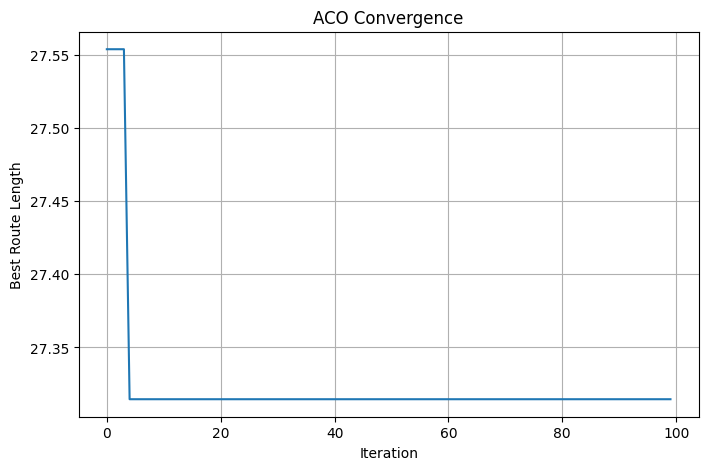

In [114]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    result["history"]
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Best Route Length"
)

plt.title(
    "ACO Convergence"
)

plt.grid()

plt.show()

Initially, the ants create random paths.</br>
Good paths are discovered.</br>
Pheromone levels on them increase.</br>
The colony converges toward the better path.

In [115]:
def plot_tsp_route(
    problem,
    route,
    title="ACO Best Route",
):

    cities = problem.cities


    plt.figure(
        figsize=(7,7)
    )


    # city points

    plt.scatter(
        cities[:,0],
        cities[:,1],
        s=80,
    )


    # city labels

    for i, city in enumerate(cities):

        plt.text(
            city[0],
            city[1],
            str(i),
            fontsize=12,
        )


    # complete route

    full_route = (
        list(route)
        +
        [route[0]]
    )


    for i in range(
        len(full_route)-1
    ):

        city_a = full_route[i]

        city_b = full_route[i+1]


        x_values = [
            cities[city_a][0],
            cities[city_b][0],
        ]

        y_values = [
            cities[city_a][1],
            cities[city_b][1],
        ]


        plt.plot(
            x_values,
            y_values,
        )


    plt.title(
        title
    )

    plt.xlabel(
        "X"
    )

    plt.ylabel(
        "Y"
    )

    plt.grid()

    plt.show()

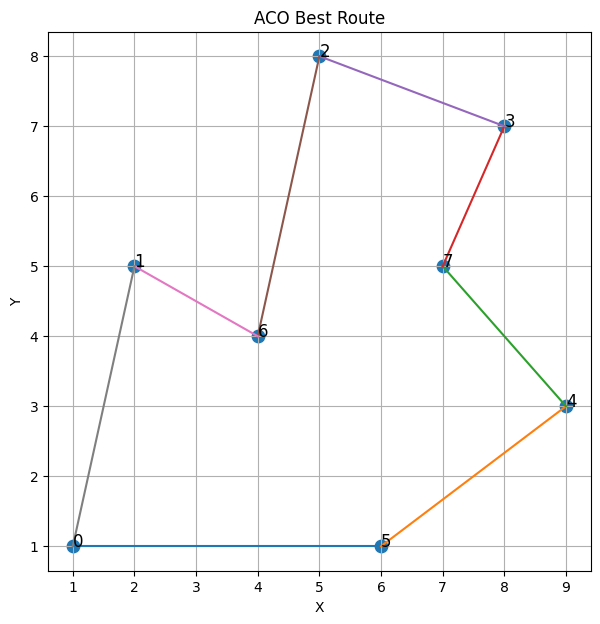

In [116]:
plot_tsp_route(
    problem,
    result["route"],
)

### ACO Small TSP Experiment Analysis

The ACO algorithm was first evaluated on a small TSP problem consisting of 8 cities.

The objective was to find a minimum-length Hamiltonian cycle where each city is visited exactly once and the route returns to the starting city.

---

#### Convergence Analysis

The convergence curve shows that ACO rapidly improves the initial solution during the first iterations.

Initially, ants generate different routes with relatively high costs. As pheromone information is updated, shorter paths receive higher pheromone values and become more likely to be selected by future ants.

After a few iterations, the best route length becomes stable, indicating that the colony has converged toward a high-quality solution.

The early convergence is expected because the search space for an 8-city TSP problem is relatively small:

$8! = 40320$

possible permutations exist.

Therefore, the algorithm can quickly identify a good solution.

---

#### Best Route Visualization

The final route visualization shows the Hamiltonian cycle found by the ant colony.

The route:

- visits all cities exactly once,
- returns to the starting city,
- satisfies the TSP constraints.

The result demonstrates that pheromone reinforcement successfully guides ants toward promising paths.

---

#### Overall Conclusion

The experiment confirms that the implemented ACO algorithm correctly performs:

- probabilistic route construction,
- pheromone-based learning,
- evaporation and reinforcement,
- convergence toward shorter routes.

However, due to the small problem size, convergence occurs quickly. Larger TSP instances are required to better evaluate the exploration capability and scalability of ACO.

<h3> Step 6:  Testing On A Bigger Problem </h3>

Generate Random Cities

In [127]:
np.random.seed(42)

cities = np.random.rand(
    50,
    2
)

Create Complete Graph

In [128]:
graph = create_complete_graph(
    len(cities)
)

Create Problem

In [129]:
problem = TSPProblem(
    cities,
    graph,
)

Run ACO

In [130]:
result = ant_colony_optimization(
    problem,
    num_ants=100,
    iterations=100,
    alpha=1.0,
    beta=3.0,
    evaporation_rate=0.3,
    q=1.0,
)

In [131]:
print(
    "Best Route:"
)

print(
    result["route"]
)

print(
    "\nBest Length:"
)

print(
    result["length"]
)

Best Route:
[33, 45, 22, 12, 4, 37, 43, 1, 46, 47, 19, 48, 9, 30, 42, 11, 23, 8, 32, 13, 20, 29, 28, 49, 2, 7, 18, 41, 39, 24, 15, 10, 14, 38, 35, 6, 31, 44, 40, 17, 25, 26, 27, 0, 34, 16, 5, 21, 3, 36]

Best Length:
5.657917262194308


Plotting the Route

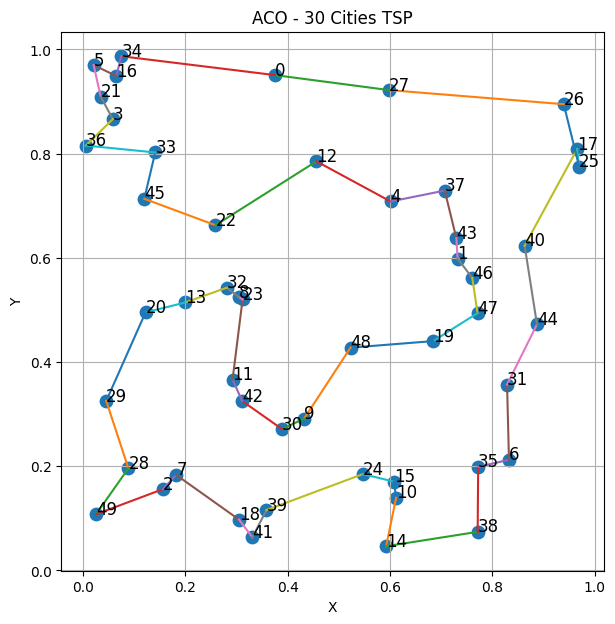

In [132]:
plot_tsp_route(
    problem,
    result["route"],
    title="ACO - 30 Cities TSP"
)

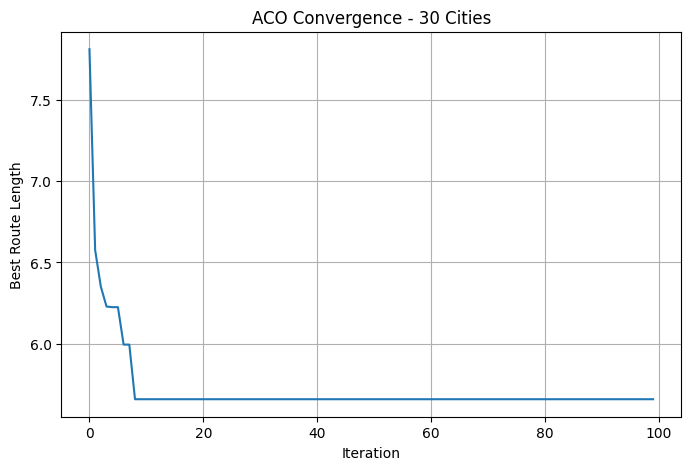

In [133]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    result["history"]
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Best Route Length"
)

plt.title(
    "ACO Convergence - 30 Cities"
)

plt.grid()

plt.show()

### ACO Large TSP Experiment Analysis

The ACO algorithm was evaluated on a larger Travelling Salesman Problem consisting of 30 cities.

Unlike the small-scale experiment, the search space is significantly larger:

$30! \approx 2.65 \times 10^{32}$

possible routes exist, making exhaustive search impractical.

Therefore, the objective is to evaluate whether pheromone-based learning can guide the colony toward high-quality solutions.

---

#### Best Route Analysis

The obtained solution was:

$[33,45,22,12,4,...,21,3,36]$

with a total route length of:

$L = 5.6579$

The visualization confirms that:

- Every city is visited exactly once.
- The route forms a complete cycle by returning to the starting city.
- The solution satisfies all TSP constraints.

The generated route demonstrates that pheromone reinforcement successfully identifies promising connections between cities.

---

#### Convergence Analysis

The convergence curve shows a rapid improvement during the first iterations.

Initially, ants generate diverse random solutions with relatively large route lengths. As pheromone information accumulates, shorter paths become more attractive and the best route length decreases.

After approximately the first 10-15 iterations, the solution becomes stable, indicating convergence of the colony.

The plateau after convergence shows that the algorithm has reached a stable solution under the selected parameters:

- Number of ants = 50
- Iterations = 200
- Alpha = 1
- Beta = 3
- Evaporation rate = 0.3

---

#### Comparison with Small TSP

Compared with the 8-city problem, the larger problem shows:

| Property | 8 Cities | 30 Cities |
|---|---|---|
| Search space | Small | Extremely large |
| Convergence speed | Very fast | Slower |
| Importance of pheromone | Lower | Higher |
| Exploration requirement | Low | High |

The larger problem better demonstrates the capability of ACO because the algorithm must balance exploration of new routes and exploitation of learned pheromone information.

---

#### Conclusion

The experiment confirms that the implemented ACO algorithm can effectively solve larger combinatorial optimization problems.

The algorithm successfully:
- constructs feasible routes,
- learns from previous solutions through pheromone updates,
- improves route quality over iterations,
- converges toward a stable solution.

However, further improvement can be achieved by tuning ACO parameters or using advanced variants such as elitist Ant System or Max-Min Ant System.

<h3> Step 7: ACO Parameter Analysis </h3>

In ACO, three main parameters control the algorithm's behavior:

α (Alpha) → Importance of pheromone (past experience)</br>
β (Beta) → Importance of heuristic (distance information)</br>
ρ (Evaporation Rate) → Rate at which previous experiences are forgotten

The goal is not to find the global optimum; rather, the aim is to understand how changing each parameter affects the colony's behavior.

Increasing alpha improved convergence speed because ants relied more on previously discovered good paths. However, very large alpha values reduced exploration and increased the risk of premature convergence.

Increasing beta caused ants to prefer shorter edges more strongly. Moderate beta values provided a good balance between greedy selection and pheromone-based learning.

The evaporation rate controlled the exploration-exploitation trade-off. Low evaporation preserved historical information, while higher evaporation encouraged exploration.

<h3> Step 7.1: Effect of Alpha (α) </h3>

Alpha controls how much we rely on past experience.

In [135]:
alpha_values = [
    0.5,
    1,
    2,
    3,
]

alpha_results = {}

for alpha in alpha_values:
    result = ant_colony_optimization(
        problem,
        num_ants=100,
        iterations=100,
        alpha=alpha,
        beta=3,
        evaporation_rate=0.3,
        q=1,
    )

    alpha_results[alpha] = (
        result["length"]
    )

    print(
        f"Alpha = {alpha} --> Best Length = {result['length']}"
    )

Alpha = 0.5 --> Best Length = 5.9831964849872
Alpha = 1 --> Best Length = 5.65220919055134
Alpha = 2 --> Best Length = 5.6888963811602835
Alpha = 3 --> Best Length = 5.768983786802549


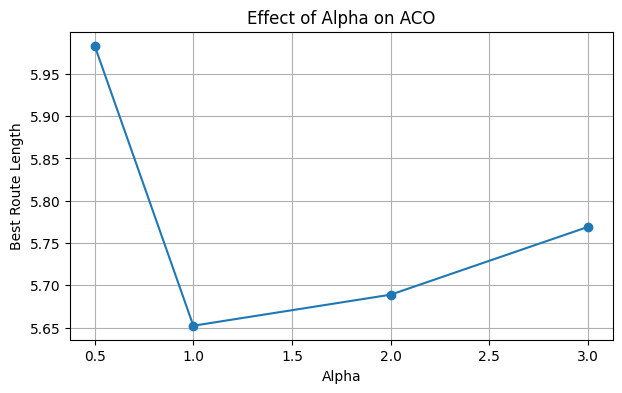

In [136]:
plt.figure(
    figsize=(7,4)
)

plt.plot(
    list(alpha_results.keys()),
    list(alpha_results.values()),
    marker="o",
)

plt.xlabel(
    "Alpha"
)

plt.ylabel(
    "Best Route Length"
)

plt.title(
    "Effect of Alpha on ACO"
)

plt.grid()

plt.show()

#### Effect of Alpha (α)

The effect of the pheromone importance parameter (α) was evaluated by testing different values:

$\alpha \in \{0.5,1,2,3\}$

The results show that the algorithm achieved the best route length when:

$\alpha = 1$

At low alpha values:

$\alpha=0.5$

the influence of pheromone information is weak, causing ants to rely less on previous experience. This increases exploration but reduces the ability to exploit promising routes.

As alpha increases:

$\alpha=2,3$

pheromone information becomes dominant. Although this improves exploitation of previously discovered good paths, very large values can reduce exploration and increase the probability of premature convergence.

The obtained results indicate that a balanced contribution between pheromone information and heuristic distance provides better performance. In this experiment, α=1 provided a suitable trade-off between exploration and exploitation.

<h3> Step 7.2: Effect of Beta (β) </h3>

Beta controls the importance of distance.

In [137]:
beta_values = [
    1,
    2,
    3,
    5,
]

beta_results = {}

for beta in beta_values:
    result = ant_colony_optimization(
        problem,
        num_ants=100,
        iterations=100,
        alpha=1,
        beta=beta,
        evaporation_rate=0.3,
        q=1,
    )

    beta_results[beta] = (
        result["length"]
    )

    print(
        f"Beta = {beta} --> Best Length = {result['length']}"
    )

Beta = 1 --> Best Length = 6.004054651790623
Beta = 2 --> Best Length = 5.682205125317572
Beta = 3 --> Best Length = 5.64626074527449
Beta = 5 --> Best Length = 5.6888963811602835


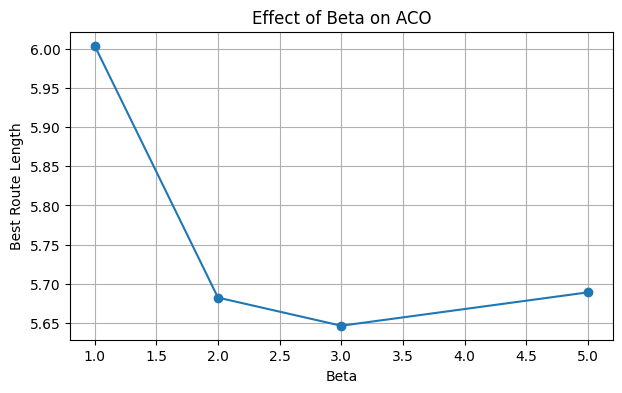

In [138]:
plt.figure(
    figsize=(7,4)
)

plt.plot(
    list(beta_results.keys()),
    list(beta_results.values()),
    marker="o",
)

plt.xlabel(
    "Beta"
)

plt.ylabel(
    "Best Route Length"
)

plt.title(
    "Effect of Beta on ACO"
)

plt.grid()

plt.show()

#### Effect of Beta (β)

The effect of the heuristic importance parameter (β) was evaluated using different values:

$
\beta \in \{1,2,3,5\}
$

Beta controls the influence of heuristic information, which is based on the inverse distance between cities:

$
\eta_{ij}=\frac{1}{d_{ij}}
$

The results show that:

$
\beta=3
$

achieved the shortest route length among the tested values.

When beta was small:

$
\beta=1
$

the influence of distance information was weak, and ants relied more on pheromone information. This reduced the ability to select geographically efficient transitions.

Increasing beta improved the solution quality because ants gave more importance to shorter edges. However, excessively large beta values:

$
\beta=5
$

caused a slight degradation because the algorithm became more greedy and focused too much on locally short edges, reducing exploration of alternative routes.

Therefore, a moderate beta value provided a better balance between exploration and exploitation. In this experiment, β=3 resulted in the best performance.

<h3> Step 7.3: Effect of Evaporation Rate (ρ) </h3>

In [139]:
rho_values = [
    0.1,
    0.3,
    0.5,
    0.7,
]

rho_results = {}

for rho in rho_values:
    result = ant_colony_optimization(
        problem,
        num_ants=100,
        iterations=100,
        alpha=1,
        beta=3,
        evaporation_rate=rho,
        q=1,
    )

    rho_results[rho] = (
        result["length"]
    )

    print(
        f"Rho = {rho} --> Best Length = {result['length']}"
    )

Rho = 0.1 --> Best Length = 5.619895988182901
Rho = 0.3 --> Best Length = 5.64626074527449
Rho = 0.5 --> Best Length = 5.667510173353047
Rho = 0.7 --> Best Length = 5.6198959881829005


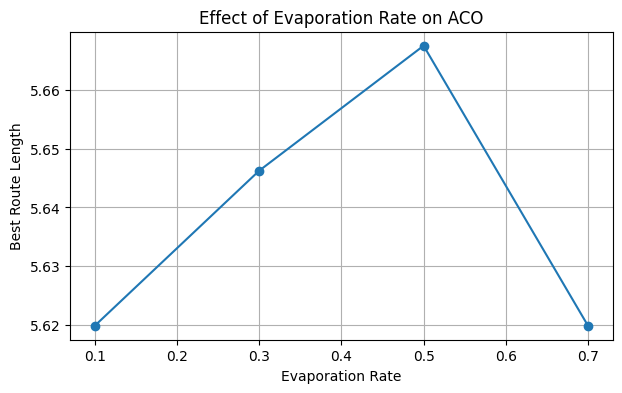

In [140]:
plt.figure(
    figsize=(7,4)
)

plt.plot(
    list(rho_results.keys()),
    list(rho_results.values()),
    marker="o",
)

plt.xlabel(
    "Evaporation Rate"
)

plt.ylabel(
    "Best Route Length"
)

plt.title(
    "Effect of Evaporation Rate on ACO"
)

plt.grid()

plt.show()

#### Effect of Evaporation Rate (ρ)

The influence of pheromone evaporation rate was evaluated using:

$
\rho \in \{0.1,0.3,0.5,0.7\}
$

The evaporation rate controls how quickly previous pheromone information is forgotten:

$
\tau_{ij} \leftarrow (1-\rho)\tau_{ij}
$

The results show that the performance difference between tested evaporation rates is relatively small.

Low evaporation rate:

$
\rho=0.1
$

preserves historical pheromone information for longer periods. This increases exploitation and allows the colony to strongly follow previously discovered good routes.

Higher evaporation rate:

$
\rho=0.7
$

causes faster forgetting of previous paths, increasing exploration and preventing excessive dependence on old solutions.

The intermediate value:

$
\rho=0.5
$

showed slightly worse performance because the balance between exploration and exploitation was not optimal for this specific problem.

Overall, the results indicate that evaporation rate mainly controls the exploration-exploitation trade-off. Both low and high evaporation rates can perform well depending on the problem characteristics.